# 14 · Weekly and daily data in one model (I1)

Financial prices, fuel sales, card payments, electricity load, mobility and online
search data arrive every day or every week. The classic nowcasting models work on a
monthly grid, so this information has to be averaged into months and its timeliness
is lost until the month closes. Bańbura, Giannone & Reichlin (2011) and Lewis, Mertens
& Stock (2020, the NY Fed *Weekly Economic Index*) show the value of a finer grid.

`nowcastbox` lets the **base grid** be weekly (or daily). Lower-frequency series are
stored in the last base period of their own period, and their link to the latent
high-frequency series is an aggregation whose weights **depend on the calendar**: a
month has four or five weeks, a quarter thirteen or fourteen (innovation I1,
generalising Mariano & Murasawa, 2003). The measurement equation of the EM becomes
time varying. Estimation, news decompositions, the nowcast tracker, density nowcasts
and diagnostics all work on the weekly grid.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils import SEED, display, md, network_enabled, setup, show

import nowcastbox as nb
from nowcastbox.core.frequency import AggregationType

setup()

## 1. Calendar-dependent aggregation weights

For an average (e.g. a monthly mean of a weekly series), the weights are $1/k$ with
$k$ the number of weeks of the month. For growth rates of a flow variable, the
Mariano-Murasawa triangle stretches with the length of the current and previous
periods:

In [2]:
display(
    pd.DataFrame(
        {
            "4 weeks after 4": pd.Series(AggregationType.GROWTH_RATE.calendar_weights(4, 4)),
            "5 weeks after 4": pd.Series(AggregationType.GROWTH_RATE.calendar_weights(5, 4)),
            "average of 5 weeks": pd.Series(AggregationType.AVERAGE.calendar_weights(5)),
        }
    )
    .round(3)
    .T.fillna("")
)

,0,1,2,3,4,5,6,7
4 weeks after 4,0.25,0.5,0.75,1.0,0.75,0.5,0.25,
5 weeks after 4,0.20,0.4,0.60,0.8,1.00,0.75,0.5,0.25
average of 5 weeks,0.20,0.2,0.20,0.2,0.20,,,


## 2. A simulated weekly economy

A latent weekly activity factor $g_t$ (AR(1), persistence 0.95) drives

* five **weekly** financial indicators, published two days after the week ends;
* four **monthly** activity indicators (monthly averages), published 35 days after the
  month ends;
* quarterly **GDP** (quarterly average of a noisy weekly latent series), published 60
  days after the quarter ends.

`MixedFrequencyData.from_series` takes each series on its **native** index and builds
the weekly panel (a week belongs to the month and quarter in which it ends).

In [3]:
rng = np.random.default_rng(SEED)
weeks = pd.period_range("2012-01-02", "2024-12-29", freq="W")
T = len(weeks)
g = np.zeros(T)
for t in range(1, T):
    g[t] = 0.95 * g[t - 1] + 0.3 * rng.standard_normal()
month = pd.PeriodIndex([w.end_time.to_period("M") for w in weeks])
quarter = month.asfreq("Q")

weekly = {
    f"fin{i}": pd.Series(g * rng.uniform(0.6, 1.0) + 0.6 * rng.standard_normal(T), index=weeks)
    for i in range(5)
}
monthly = {}
for i in range(4):
    x = pd.Series(g * rng.uniform(0.6, 1.0) + 0.8 * rng.standard_normal(T), index=weeks)
    m = x.groupby(month).mean()
    monthly[f"act{i}"] = m.set_axis(pd.PeriodIndex(m.index, freq="M"))
latent_gdp = pd.Series(g + 0.5 * rng.standard_normal(T), index=weeks).groupby(quarter).mean()
gdp = latent_gdp.set_axis(pd.PeriodIndex(latent_gdp.index, freq="Q"))

delays = {**dict.fromkeys(weekly, 2), **dict.fromkeys(monthly, 35), "gdp": 60}
averages = {**dict.fromkeys(monthly, "average"), "gdp": "average"}
panel_w = nb.MixedFrequencyData.from_series(
    {**weekly, **monthly, "gdp": gdp},
    base_frequency="W",
    release_delays=delays,
    aggregations=averages,
)
print(panel_w)
display(panel_w.data.loc[panel_w.index[-6] :].round(2))

MixedFrequencyData(n_periods=678, n_series=10, base=weekly, 2012-01-02/2012-01-08..2024-12-23/2024-12-29, weekly=5, monthly=4, quarterly=1)


,fin0,fin1,fin2,fin3,fin4,act0,act1,act2,act3,gdp
period,,,,,,,,,,
2024-11-18/2024-11-24,-1.23,-0.35,0.65,0.15,1.14,0.21,-0.78,-0.79,-0.38,NaN
2024-11-25/2024-12-01,-0.63,0.68,-0.27,-0.78,-1.06,NaN,NaN,NaN,NaN,NaN
2024-12-02/2024-12-08,0.31,-0.53,-0.52,0.16,-1.71,NaN,NaN,NaN,NaN,NaN
2024-12-09/2024-12-15,0.55,-0.92,-0.35,0.26,0.62,NaN,NaN,NaN,NaN,NaN
2024-12-16/2024-12-22,0.05,-0.70,-0.11,-0.84,0.04,NaN,NaN,NaN,NaN,NaN
2024-12-23/2024-12-29,0.90,-0.69,0.65,-0.49,0.22,-0.26,-0.60,0.14,-0.02,-0.22


For comparison, the **monthly** version of the same information: the weekly series
are averaged into months (and are therefore only available when the month closes).

In [4]:
weekly_as_monthly = {
    k: v.groupby(month).mean().set_axis(pd.PeriodIndex(sorted(set(month)), freq="M"))
    for k, v in weekly.items()
}
panel_m = nb.MixedFrequencyData.from_series(
    {**weekly_as_monthly, **monthly, "gdp": gdp},
    base_frequency="M",
    release_delays=delays,
    aggregations=averages,
)
res_w = nb.MixedFreqDFM(n_factors=1, max_iter=100).fit(panel_w, target="gdp")
res_m = nb.MixedFreqDFM(n_factors=1, max_iter=100).fit(panel_m, target="gdp")
md(
    f"Weekly-grid model: {panel_w.n_periods} weeks, EM converged in {res_w.n_iter} "
    f"iterations; monthly-grid model: {panel_m.n_periods} months, {res_m.n_iter} iterations."
)

Weekly-grid model: 678 weeks, EM converged in 11 iterations; monthly-grid model: 156 months, 3 iterations.

## 3. Does the weekly grid pay off within the quarter?

For each of the last eight quarters and each Friday of the quarter (plus the five
weeks after it, before GDP is released), we build the information set of that day with
`as_of` and compute the nowcast with **fixed parameters** (`results.predict(vintage)`
re-runs the Kalman smoother). Parameters are estimated on the full sample — fine for
a simulation, where the point is the information flow, not parameter estimation.

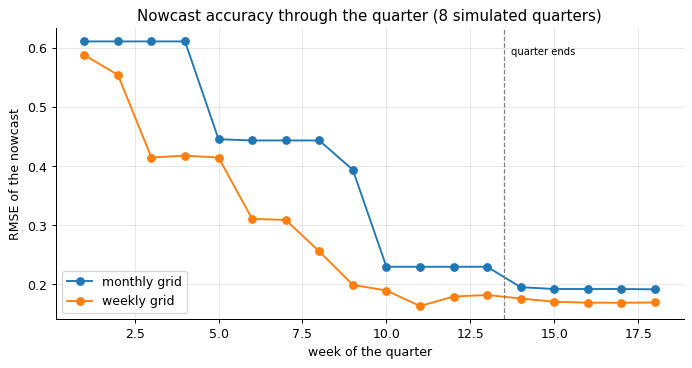

In [5]:
records = []
for q in pd.period_range("2023Q1", "2024Q4", freq="Q"):
    start = q.start_time
    for date in pd.date_range(
        start + pd.Timedelta(days=4), q.end_time + pd.Timedelta(days=35), freq="7D"
    ):
        week_of_q = (date - start).days // 7 + 1
        w_slot = panel_w.index[panel_w.index.asfreq("D", "end").to_timestamp() <= q.end_time][-1]
        m_slot = q.asfreq("M", "end")
        now_w = res_w.predict(panel_w.as_of(date)).loc[w_slot, "gdp"]
        now_m = res_m.predict(panel_m.as_of(date)).loc[m_slot, "gdp"]
        for name, value in (("weekly grid", now_w), ("monthly grid", now_m)):
            records.append(
                {"quarter": q, "week": week_of_q, "model": name, "error": float(gdp.loc[q] - value)}
            )
err = pd.DataFrame(records)
rmse = err.groupby(["week", "model"])["error"].apply(lambda e: np.sqrt(np.mean(e**2))).unstack()  # noqa: PD010
fig, ax = plt.subplots()
for name in rmse.columns:
    ax.plot(rmse.index, rmse[name], marker="o", label=name)
ax.axvline(13.5, color="grey", ls="--", lw=1)
ax.text(13.7, ax.get_ylim()[1] * 0.95, "quarter ends", fontsize=8, va="top")
ax.set_xlabel("week of the quarter")
ax.set_ylabel("RMSE of the nowcast")
ax.set_title("Nowcast accuracy through the quarter (8 simulated quarters)")
ax.legend()
show(fig, "14_weekly_vs_monthly")

In [6]:
gain = 1 - rmse["weekly grid"] / rmse["monthly grid"]
md(
    f"Within the quarter the weekly grid reduces the RMSE by up to **{gain.loc[1:13].max():.0%}** "
    f"(average over weeks 1–13: {gain.loc[1:13].mean():.0%}); after the quarter ends, "
    f"when the monthly averages of the weekly series are complete, the two grids "
    f"converge (average gain in weeks 14+: {gain.loc[14:].mean():.0%})."
)

Within the quarter the weekly grid reduces the RMSE by up to **49%** (average over weeks 1–13: 25%); after the quarter ends, when the monthly averages of the weekly series are complete, the two grids converge (average gain in weeks 14+: 11%).

The gains come from **timeliness**: on the weekly grid each new week of financial data
updates the factor immediately, while on the monthly grid the same data enter only as
a monthly average once the month is complete. With a persistent factor the weekly
signal is informative about the whole quarter, so the nowcast converges to the final
value weeks earlier — the mechanism behind weekly indices such as the NY Fed WEI.

## 3b. What moved the nowcast this week? News on the weekly grid

The news decomposition (Bańbura & Modugno, 2014) works with the time-varying
measurement equation: the model is rebuilt for the length of each vintage and every
release - a week of financial data, a monthly average - gets its weight and impact.
Below, the revision of the 2024Q4 nowcast between two Fridays of December 2024.

2024Q4 nowcast: -0.263 on 6 Dec -> -0.306 on 13 Dec (5 releases; identity holds: True).

,series,reference_period,actual,expected,impact
4,fin4,2024-12-02/2024-12-08,-1.714,-0.230,-0.061
3,fin3,2024-12-02/2024-12-08,0.161,-0.210,0.020
0,fin0,2024-12-02/2024-12-08,0.306,-0.214,0.020
2,fin2,2024-12-02/2024-12-08,-0.520,-0.270,-0.013
1,fin1,2024-12-02/2024-12-08,-0.528,-0.334,-0.009


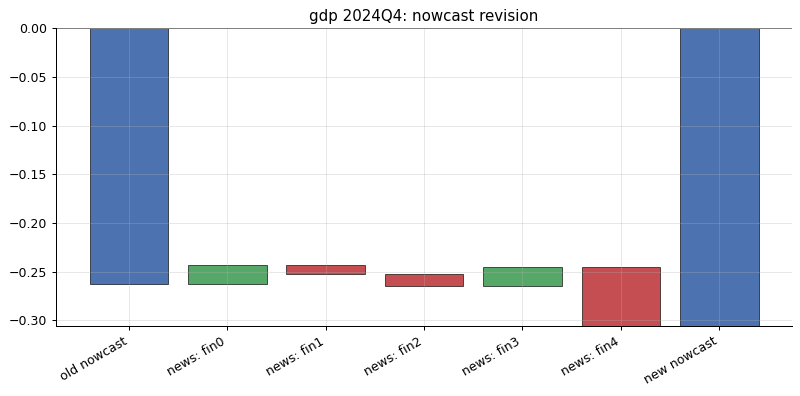

In [7]:
old_v = panel_w.as_of("2024-12-06")
new_v = panel_w.as_of("2024-12-13")
news = res_w.news(old_v, new_v, "2024Q4")
md(
    f"2024Q4 nowcast: {news.old_nowcast:.3f} on 6 Dec -> {news.new_nowcast:.3f} on 13 Dec "
    f"({news.n_releases} releases; identity holds: {news.check_identity()})."
)
display(
    news.top_releases(6)[["series", "reference_period", "actual", "expected", "impact"]].round(
        {"actual": 3, "expected": 3, "impact": 3}
    )
)
fig = news.plot("waterfall", by="series")
show(fig, "14_weekly_news")

## 4. Real data: daily Brazilian financial series (network)

The same construction with real data: daily PTAX exchange rate and daily Selic rate
from the BCB's SGS (averaged into weeks), the monthly IBC-Br and quarterly GDP from the
shipped dataset. The daily downloads require internet access (opt-in with
`NOWCASTBOX_EXAMPLES_NETWORK=1`); offline, the cell is skipped.

In [8]:
if network_enabled():  # --- network cell --------------------------------------------
    daily = nb.data_sources.fetch_sgs({"ptax": 1, "selic": 11}, start="2012-01-01")
    wk = daily.groupby(daily.index.asfreq("W")).mean()
    real_weekly = {
        "ptax": np.log(wk["ptax"]).diff().dropna(),  # weekly log-change
        "selic": wk["selic"].diff().dropna(),  # weekly change of the daily rate
    }
    br = nb.load_brazil_nowcast().select(["pib", "ibc_br"]).truncate("2012-01", None)
    br_panel = nb.apply_transforms(br.data, br.transform)
    native = {c: br_panel.to_native(c).dropna() for c in br_panel.columns}
    real = nb.MixedFrequencyData.from_series(
        {**real_weekly, **native},
        base_frequency="W",
        release_delays={"ptax": 1, "selic": 1, "ibc_br": 46, "pib": 62},
        aggregations={"ibc_br": "average", "pib": "average"},
    )
    real_res = nb.MixedFreqDFM(n_factors=1, max_iter=100).fit(real, target="pib")
    print(real)
    display(real_res.nowcast[["observed", "in_sample", "out_of_sample"]].tail(4))
else:  # --- offline ------------------------------------------------------------------
    print(
        "Offline run: the daily SGS download is skipped. Set NOWCASTBOX_EXAMPLES_NETWORK=1 "
        "to estimate the weekly Brazilian model (PTAX, Selic, IBC-Br, GDP)."
    )

Offline run: the daily SGS download is skipped. Set NOWCASTBOX_EXAMPLES_NETWORK=1 to estimate the weekly Brazilian model (PTAX, Selic, IBC-Br, GDP).


### Notes and limits

* Daily grids work the same way (`base_frequency="D"`), at a much higher computational
  cost (T ≈ 250 × years); weekly averages of daily data are usually the better
  trade-off.
* News decompositions, the tracker and level contributions rebuild the time-varying
  measurement equation for every vintage; the parametric density bootstrap simulates
  from it. The block bootstrap needs a fixed number of weeks per target period and is
  not available on weekly grids.
* `TwoStepDFM`, bridge equations and the benchmarks still need fixed-ratio frequency
  pairs (monthly/quarterly/annual): put them on a monthly grid.
* `nb.simulate.weekly_dfm` draws weekly + monthly + quarterly panels from a known model.

### References

* Bańbura, M., Giannone, D. & Reichlin, L. (2011). Nowcasting. *Oxford Handbook of
  Economic Forecasting*, 193–224.
* Lewis, D. J., Mertens, K., Stock, J. H. & Trivedi, M. (2022). Measuring real activity
  using a weekly economic index. *Journal of Applied Econometrics*, 37(4), 667–687.
* Mariano, R. S. & Murasawa, Y. (2003). *Journal of Applied Econometrics*, 18(4),
  427–443.
* Aruoba, S. B., Diebold, F. X. & Scotti, C. (2009). Real-time measurement of business
  conditions. *JBES*, 27(4), 417–427.